In [2]:
import PLL_FUNCS as PLL
import OPTICS_FUNCS as OPTICS
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy import integrate


Estimated Noise Variance: 1.33e+05
Standard Deviation of Noise: 1.12e+05


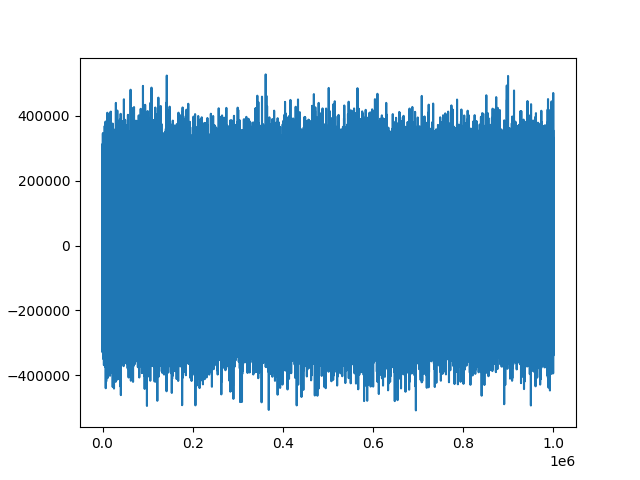

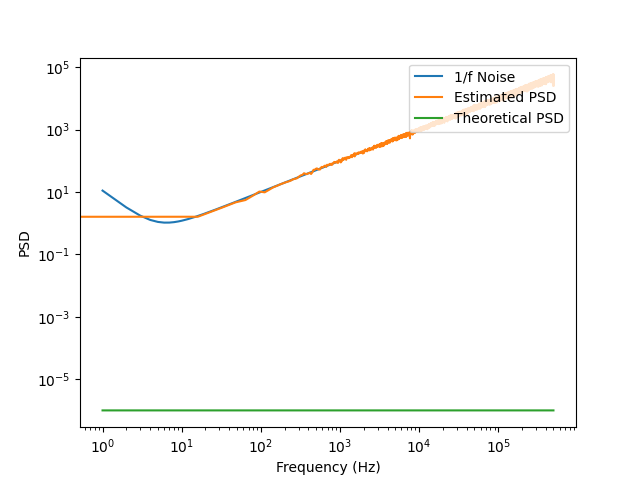

In [3]:
%matplotlib widget
N = int(1e6) # Number of samples
Fs = 1e6 # 1MHz
freqs = PLL.get_single_freqs(N, Fs)

whiteNoiseLevel = 1e-6

freqCopy = np.copy(freqs)
phaseNoise =  10 / freqCopy**2 +  1 / freqCopy + 0.1 * freqCopy

noise_psd = np.ones_like(freqs) * whiteNoiseLevel
noise = PLL.psdnoise(phaseNoise, N, Fs, complex=False)

estimatedPsd = integrate.cumtrapz(phaseNoise, freqs, initial=0)
print(f"Estimated Noise Variance: {np.sqrt(estimatedPsd[-1]*np.sqrt(2)):.2e}")



tAray = np.arange(N) / Fs
f = 50e3
V = 10 * np.sin(2 * np.pi * f * tAray)
noise += V



plt.figure()
plt.plot(noise)

stdDeviation = np.std(noise)
print(f"Standard Deviation of Noise: {stdDeviation:.2e}")

nperseg = N // 16
f, Pxx = signal.welch(noise, fs=Fs, nperseg=nperseg, scaling='density')

plt.figure()
plt.plot(freqs, phaseNoise, label='1/f Noise')
plt.plot(f, Pxx, label='Estimated PSD')
plt.plot(freqs, noise_psd, label='Theoretical PSD')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend(loc = 'upper right')

In [ ]:
freqs = PLL.get_single_freqs(N, Fs)
level = 1e-14
RPD = 0.95
A = 1 # Just going to use 1 for now
# Need to remember that this is a combination of LO and signal. S_phi(f) = 2 * S(f) / A^2. S(f) = A^2 * S_phi(f)/2 for A = 1. Need to use this! To ensure noise coupling is correct.
Psig = 1e-8
Wavelength = 1550e-9
AdditiveLevel = A**2 * OPTICS.CalcAdditiveShotPSD(Psig, Wavelength, RPD = RPD) / 2 # This effectively becomes shot noise due to LO.
print(f"AdditiveLevel: {AdditiveLevel:.2e} rad^2/Hz")
    

In [20]:
%matplotlib widget
N = int(1e6) # Number of samples
Fs = 1e6 # 1MHz
freqs = PLL.get_single_freqs(N, Fs)

whiteNoiseLevel = 1e-6

freqCopy = np.copy(freqs)
phaseNoise =  10 / freqCopy**2 +  1 / freqCopy + 0.1 * freqCopy

noise_psd = np.ones_like(freqs) * whiteNoiseLevel
noise = PLL.psdnoise(noise_psd, N, Fs, complex=False)


Window Size: 1, Standard Deviation of Averaged Data: 1.12e+05
Window Size: 1, Average Standard Deviation: 1.12e+05
Window Size: 10, Standard Deviation of Averaged Data: 1.68e+04
Window Size: 10, Average Standard Deviation: 1.68e+04
Window Size: 50, Standard Deviation of Averaged Data: 7.92e+03
Window Size: 50, Average Standard Deviation: 7.92e+03
Window Size: 100, Standard Deviation of Averaged Data: 7.32e+03
Window Size: 100, Average Standard Deviation: 7.32e+03
Window Size: 150, Standard Deviation of Averaged Data: 7.19e+03
Window Size: 150, Average Standard Deviation: 7.19e+03
Window Size: 300, Standard Deviation of Averaged Data: 7.10e+03
Window Size: 300, Average Standard Deviation: 7.10e+03
Window Size: 1000, Standard Deviation of Averaged Data: 7.07e+03
Window Size: 1000, Average Standard Deviation: 7.07e+03
Window Size: 10000, Standard Deviation of Averaged Data: 6.96e+03
Window Size: 10000, Average Standard Deviation: 6.96e+03
Window Size: 100000, Standard Deviation of Average

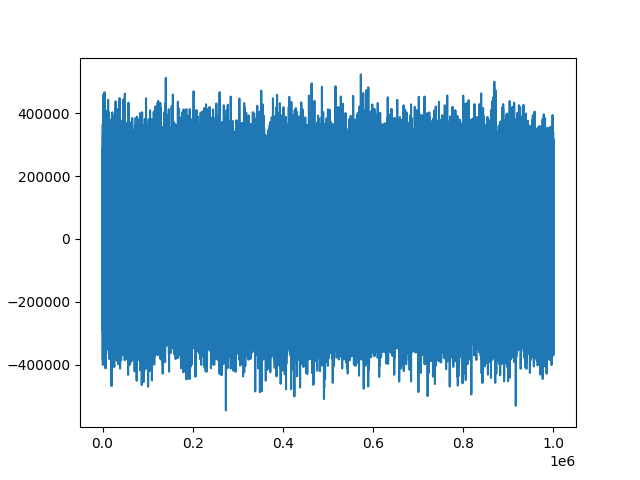

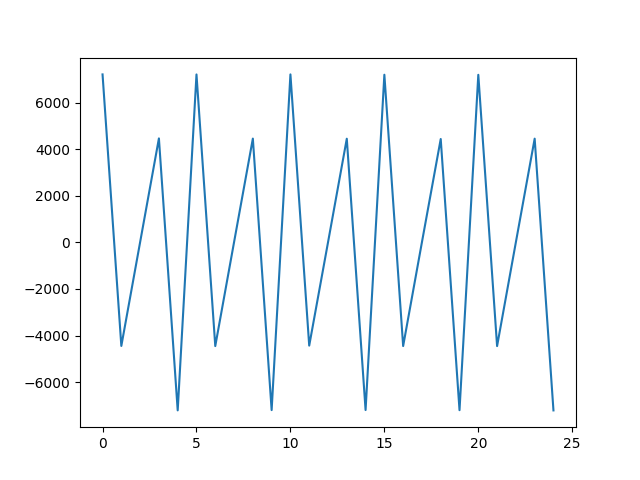

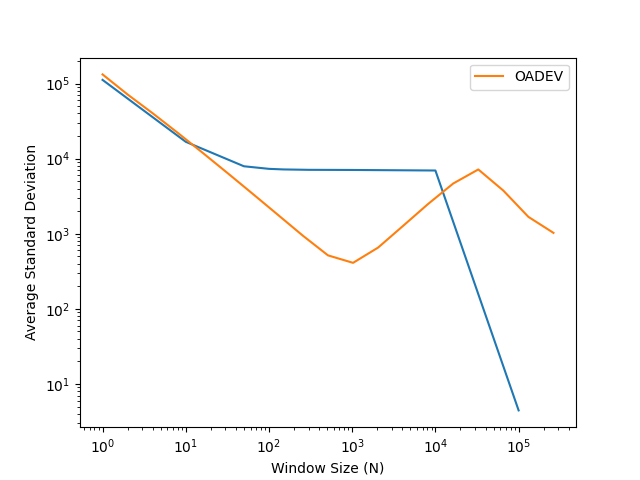

In [44]:
import allantools as AT

def movingAverageFilter(data, N):
    print("Deprecated. Using function in MSTAR_STATS.py")
    averageData = np.zeros(len(data) - N + 1)
    stdDeviations = np.zeros(len(data) - N + 1)
    
    for endPoint in range(N, len(data) + 1):
        startPoint = endPoint - N
        averageData[startPoint] = np.average(data[startPoint:endPoint])
        stdDeviations[startPoint] = np.std(data[startPoint:endPoint])
    
    return averageData, stdDeviations

def movingAverageFilterConvolve(data, N):
    averageData = np.zeros(len(data)//N)
    stdDeviations = np.zeros(len(data)//N)
    
    # convolve data with 1/N array
    for i in range(len(averageData)):
        startPoint = i * N
        endPoint = startPoint + N
        averageData[i] = np.average(data[startPoint:endPoint])
        stdDeviations[i] = np.std(data[startPoint:endPoint])
    # calculate std deviation
    return averageData, np.sqrt(stdDeviations)



def testAvg(noise, windows):
    plt.figure()
    avgDeviations = []
    calcStd = np.std(noise)
    for N in windows:
        avgData, stdDeviations = movingAverageFilterConvolve(noise, N)
        print(f"Window Size: {N}, Standard Deviation of Averaged Data: {np.std(avgData):.2e}")
        avgStandardDeviation = np.std(avgData)
        avgDeviations.append(avgStandardDeviation)
        print(f"Window Size: {N}, Average Standard Deviation: {avgStandardDeviation:.2e}")
    plt.plot(windows, avgDeviations)
    # plt.plot(windows, calcStd/np.sqrt(np.array(windows)), label='Original Std Deviation Scaled')
    # draw line for 1/N and 1/sqrt(N)
    # plt.plot(windows, 1e5*np.array(windows).astype(float)**-1, label='1/N')
    # plt.plot(windows, np.array(windows).astype(float)**-0.5, label='1/sqrt(N)')
    # calculate OADEV
    (ad_taus, adev, ad_errors, ad_ns)=AT.oadev(noise,rate=1,data_type="freq",taus=None)
    plt.plot(ad_taus, adev, label='OADEV')
    plt.legend()
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Window Size (N)')
    plt.ylabel('Average Standard Deviation')

N = int(1e6) # Number of samples
Fs = 1e6 # 1MHz
freqs = PLL.get_single_freqs(N, Fs)

whiteNoiseLevel = 1e-6

freqCopy = np.copy(freqs)
phaseNoise =  10 / freqCopy**2 +  1 / freqCopy + 0.1 * freqCopy

noise_psd = np.ones_like(freqs) * whiteNoiseLevel
noise = PLL.psdnoise(phaseNoise, N, Fs, complex=False)

tAray = np.arange(N) / Fs
f = 10
V = 10000 * np.sin(2 * np.pi * f * tAray)
noise += V
avgData, stdDeviations = movingAverageFilterConvolve(noise, int(40000))



plt.figure()
plt.plot(noise)
plt.figure()
plt.plot(avgData)

testAvg(noise, [1, 10, 50, 100, 150, 300, 1000, 10000, 100000])